In [4]:
import torch
import torchvision
import torchvision.datasets as Dataset
import matplotlib.pyplot as plt
import torch.optim as optim
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

In [5]:
#---CONFIGS---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
BATCH_SIZE = 32
EPOCHS = 500
img_dim = 1 * 28 * 28
disc_out = 1
z_dim = 128
lr = 0.0002

cuda


In [6]:
#---DATASET---
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))]
)

dataset = Dataset.MNIST(root= "data",
                        train= True,
                        transform= transform,
                        download= True)

loader = DataLoader(dataset= dataset,
                    batch_size= BATCH_SIZE,
                    shuffle= True,
                    )

100.0%
100.0%
100.0%
100.0%


In [7]:
print(f"Length of dataset: {len(dataset)}")
print(f"Total batches: {len(loader)}")
batch = next(iter(loader))
print(f"Shape of a batch: {batch[0].shape}")

Length of dataset: 60000
Total batches: 1875
Shape of a batch: torch.Size([32, 1, 28, 28])


In [8]:
#---MODELS---
class Discriminator(nn.Module):
  def __init__(self, img_dim, disc_out):
    super().__init__()

    self.disc = nn.Sequential(
        nn.Linear(img_dim, 512),
        nn.LeakyReLU(0.2),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 128),
        nn.LeakyReLU(0.2),
        nn.Linear(128, disc_out),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.disc(x)

class Generator(nn.Module):
  def __init__(self, z_dim, img_dim):
    super().__init__()

    self.gen = nn.Sequential(
        nn.Linear(z_dim, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 512),
        nn.LeakyReLU(0.2),
        nn.Linear(512, img_dim),
        nn.Tanh()
    )

  def forward(self, x):
    return self.gen(x)

In [9]:
#---TRAINING_SETUP---
disc = Discriminator(img_dim, disc_out).to(device)
gen = Generator(z_dim, img_dim).to(device)

disc_optim = optim.Adam(params= disc.parameters(), lr= lr, betas=(0.5, 0.999))
gen_optim = optim.Adam(params= gen.parameters(), lr= lr, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

fixed_noise = torch.randn(BATCH_SIZE, z_dim).to(device)

writer_fake = SummaryWriter("logs/Fake")
writer_real = SummaryWriter("logs/Real")
step = 0

In [10]:
real, _ = next(iter(loader))
print(real.shape)

torch.Size([32, 1, 28, 28])


In [11]:
real, _ = next(iter(loader))
print(real.view(-1, 784).shape)

torch.Size([32, 784])


In [12]:
noise = torch.randn(BATCH_SIZE, z_dim).to(device)
fake = gen(noise)
fake.shape

torch.Size([32, 784])

In [13]:
#---TRAINING_LOOP---
for epoch in range(EPOCHS):
  for real, _ in loader:

    real = real.view(-1, img_dim).to(device)
    noise = torch.randn(real.shape[0], z_dim).to(device)
    fake = gen(noise)

    # Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
    d_real = disc(real).view(-1)
    lossD_real = loss_fn(d_real, torch.ones_like(d_real))
    d_fake = disc(fake.detach()).view(-1)
    lossD_fake = loss_fn(d_fake, torch.zeros_like(d_fake))

    lossD = (lossD_fake + lossD_real) / 2

    disc_optim.zero_grad()

    lossD.backward()

    disc_optim.step()


    # Train Generator: max log(D(G(z)))
    output = disc(fake).view(-1)
    lossG = loss_fn(output, torch.ones_like(output))

    gen_optim.zero_grad()

    lossG.backward()

    gen_optim.step()

  if epoch % 50 == 0:
    print(f"EPOCH: {epoch}/{EPOCHS} | LOSS_D: {lossD.item():.4f} | LOSS_G: {lossG.item():.4f}")

    with torch.no_grad():
              fake_display     = gen(fixed_noise).reshape(-1, 1, 28, 28)
              real_display     = real.reshape(-1, 1, 28, 28)
              img_grid_fake    = torchvision.utils.make_grid(fake_display, normalize=True)
              img_grid_real    = torchvision.utils.make_grid(real_display, normalize=True)

              writer_fake.add_image("MNIST Fake", img_grid_fake, global_step=step)
              writer_real.add_image("MNIST Real", img_grid_real, global_step=step)
              step += 1

EPOCH: 0/500 | LOSS_D: 0.2229 | LOSS_G: 2.4934
EPOCH: 50/500 | LOSS_D: 0.4363 | LOSS_G: 1.9646
EPOCH: 100/500 | LOSS_D: 0.3158 | LOSS_G: 1.9283
EPOCH: 150/500 | LOSS_D: 0.3240 | LOSS_G: 2.2638
EPOCH: 200/500 | LOSS_D: 0.1908 | LOSS_G: 2.8389
EPOCH: 250/500 | LOSS_D: 0.1600 | LOSS_G: 2.4684
EPOCH: 300/500 | LOSS_D: 0.4548 | LOSS_G: 2.7942
EPOCH: 350/500 | LOSS_D: 0.1559 | LOSS_G: 2.4849
EPOCH: 400/500 | LOSS_D: 0.0983 | LOSS_G: 2.9223
EPOCH: 450/500 | LOSS_D: 0.1212 | LOSS_G: 3.0092


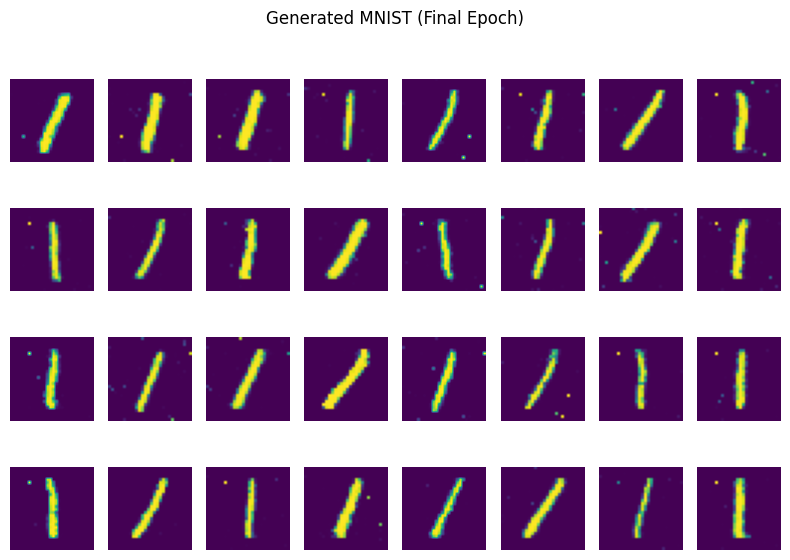

In [ ]:
with torch.no_grad():
    sample = gen(fixed_noise).reshape(-1, 1, 28, 28).cpu()
    sample = sample * 0.5 + 0.5

    fig, axes = plt.subplots(4,8, figsize=(8, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sample[i].permute(1, 2, 0).clamp(0, 1), cmap='gray')
        ax.axis("off")
    plt.suptitle("Generated MNIST (Final Epoch)")
    plt.tight_layout()
    plt.show()